# day 37 prep

The code below chat and I cooked up to extend this diffusion equation solution to 2 dimensions. As usual, chat's code is a little more complex than I would like to show students, but it is an interesting result anyway.

I want to do eigenvalue/eigenvector stuff so I need to develop a good set of material for this. 

$$ \textbf{A} \textbf{v} = \lambda \textbf{v}  $$

Here \\(\textbf{A}\\) is a matrix and \\(\textbf{v}\\) is a vector. In the context of this equation, \\(\lambda\\) is known as the eigenvalue and \\(\textbf{v}\\) is known as the eigenvector of the matrix \\(\textbf{A}\\).

But here is the thing: what does the eigenvector and eigenvalue actually mean? 



In [1]:
A = np.matrix([[2,-1],[-1,2]])

In [2]:
A

matrix([[ 2, -1],
        [-1,  2]])

In [5]:
values, vectors = np.linalg.eig(A)

In [6]:
values

array([3., 1.])

In [7]:
vectors

matrix([[ 0.70710678,  0.70710678],
        [-0.70710678,  0.70710678]])

In [8]:
K = np.array([[2,-1,0],[-1,2,-1],[0,-1,2]])
vals, vecs = np.linalg.eig(K)

In [13]:
vals, vecs

(array([3.41421356, 2.        , 0.58578644]),
 array([[-5.00000000e-01, -7.07106781e-01,  5.00000000e-01],
        [ 7.07106781e-01,  5.60339614e-16,  7.07106781e-01],
        [-5.00000000e-01,  7.07106781e-01,  5.00000000e-01]]))

eigenvalues (lambda):
mode 1: lambda = -7668.27768
mode 2: lambda = -7638.79539
mode 3: lambda = -7638.79539
mode 4: lambda = -7609.31309
mode 5: lambda = -7589.99449
mode 6: lambda = -7589.99449


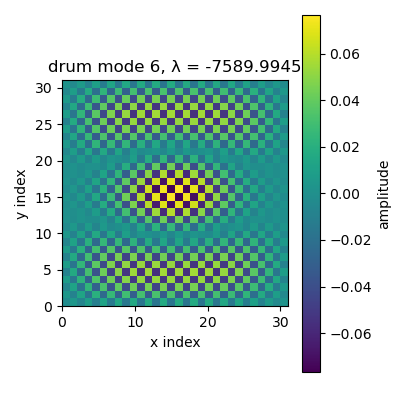

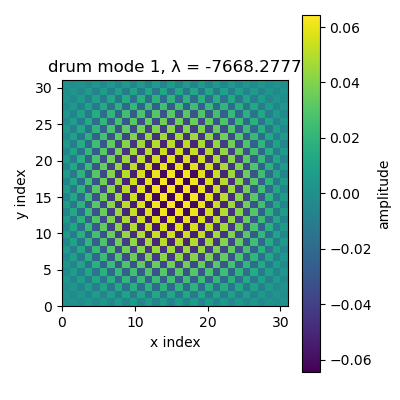

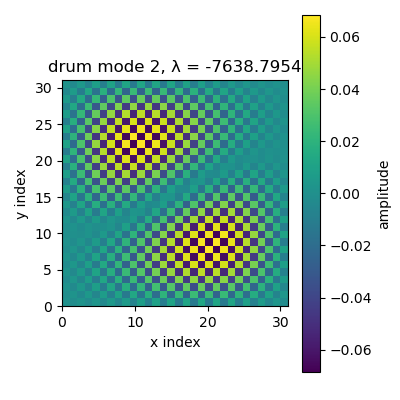

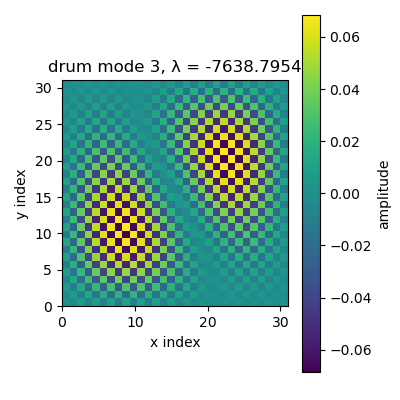

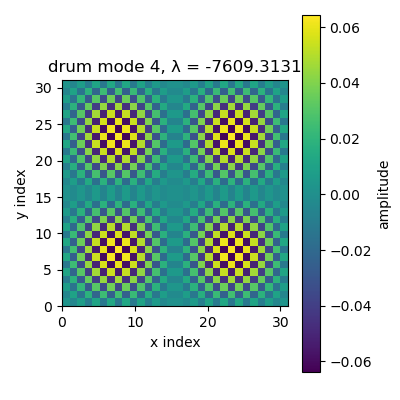

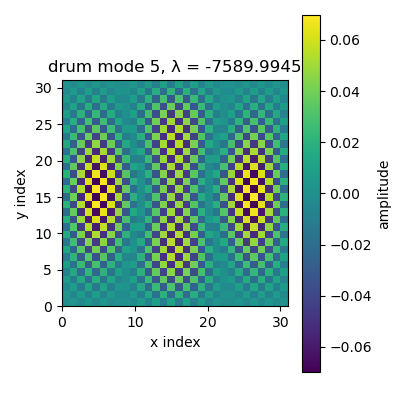

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron, eye
from scipy.sparse.linalg import eigsh

# parameters
nx = 30          # number of interior grid points in x
ny = 30          # number of interior grid points in y
k_modes = 6      # how many lowest modes to compute

# grid spacing (physical length doesn't matter here, just relative)
Lx = 1.0
Ly = 1.0
dx = Lx / (nx + 1)
dy = Ly / (ny + 1)

# 1d laplacian with dirichlet boundaries on interior points
# L1d ~ (f_{i+1} - 2 f_i + f_{i-1}) / dx^2
main_x = -2.0 * np.ones(nx)
off_x = 1.0 * np.ones(nx - 1)
Lx_1d = diags([off_x, main_x, off_x], offsets=[-1, 0, 1]) / dx**2

main_y = -2.0 * np.ones(ny)
off_y = 1.0 * np.ones(ny - 1)
Ly_1d = diags([off_y, main_y, off_y], offsets=[-1, 0, 1]) / dy**2

# 2d laplacian: L = Lx ⊗ I_y + I_x ⊗ Ly
Ix = eye(nx)
Iy = eye(ny)
L2d = kron(Lx_1d, Iy) + kron(Ix, Ly_1d)

# solve for the k_modes smallest-magnitude eigenvalues/eigenvectors
# we actually want the smallest eigenvalues (most negative for laplacian),
# but eigenfrequencies will be related to sqrt(|lambda|) up to constants.
vals, vecs = eigsh(L2d, k=k_modes, which='SA')  # 'SA' = smallest algebraic

print("eigenvalues (lambda):")
for i, lam in enumerate(vals):
    print(f"mode {i+1}: lambda = {lam:.5f}")

# prepare grid for plotting
x = np.linspace(dx, Lx - dx, nx)
y = np.linspace(dy, Ly - dy, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# plot each mode as a heatmap
for m in range(k_modes):
    mode_vec = vecs[:, m]              # length nx*ny
    mode_grid = mode_vec.reshape((nx, ny))

    plt.figure(figsize=(4, 4))
    plt.title(f"drum mode {m+1}, λ = {vals[m]:.4f}")
    plt.xlabel("x index")
    plt.ylabel("y index")

    # imshow: note origin='lower' so (0,0) is bottom-left
    im = plt.imshow(mode_grid.T, origin='lower',
                    extent=[0, nx+1, 0, ny+1])
    plt.colorbar(im, label="amplitude")
    plt.tight_layout()

plt.show()

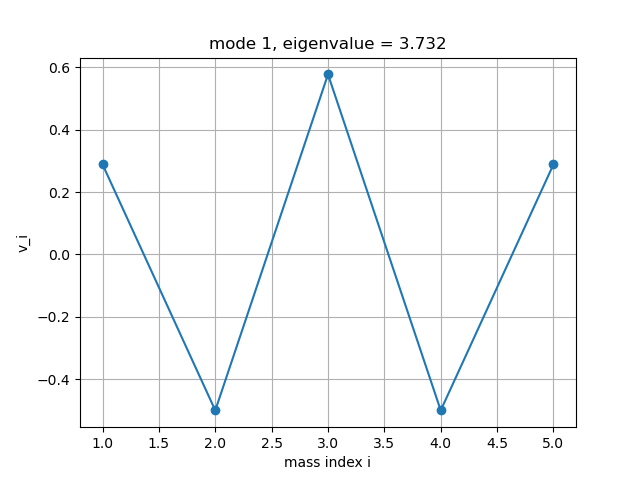

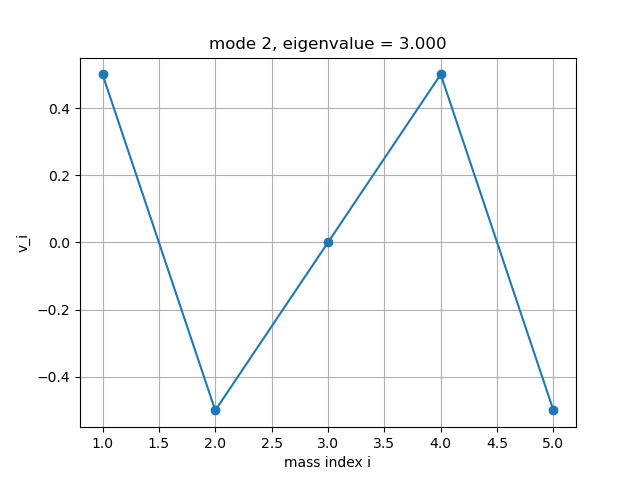

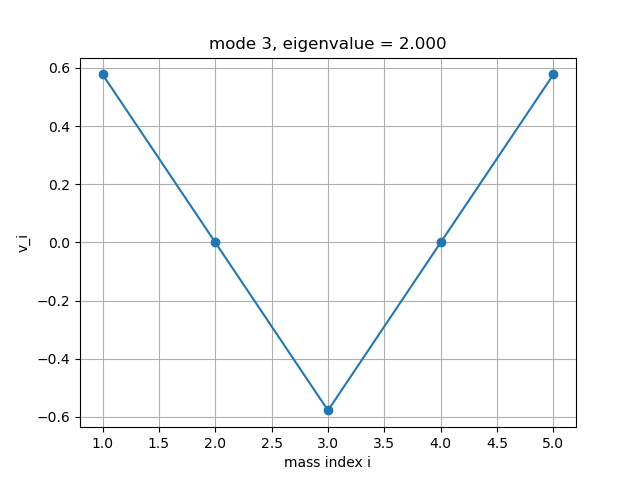

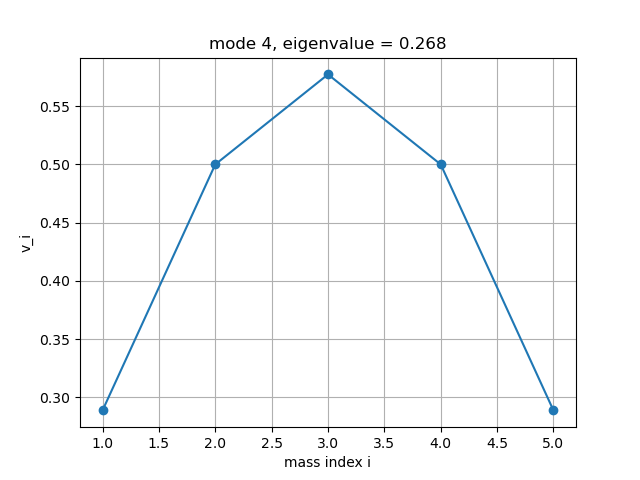

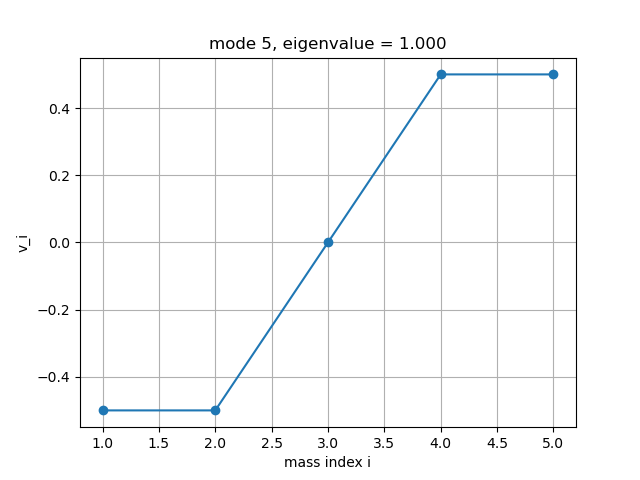

In [17]:
# build stiffness matrix for N masses
N = 5
K = np.zeros((N, N))
for i in range(N):
    if i > 0:
        K[i, i-1] = -1
    if i < N-1:
        K[i, i+1] = -1
    K[i, i] = 2

vals, vecs = np.linalg.eig(K)

# plot each eigenvector
for k in range(N):
    plt.figure()
    plt.plot(range(1, N+1), vecs[:, k], marker='o')
    plt.title(f"mode {k+1}, eigenvalue = {vals[k]:.3f}")
    plt.xlabel("mass index i")
    plt.ylabel("v_i")
    plt.grid()
    plt.show()

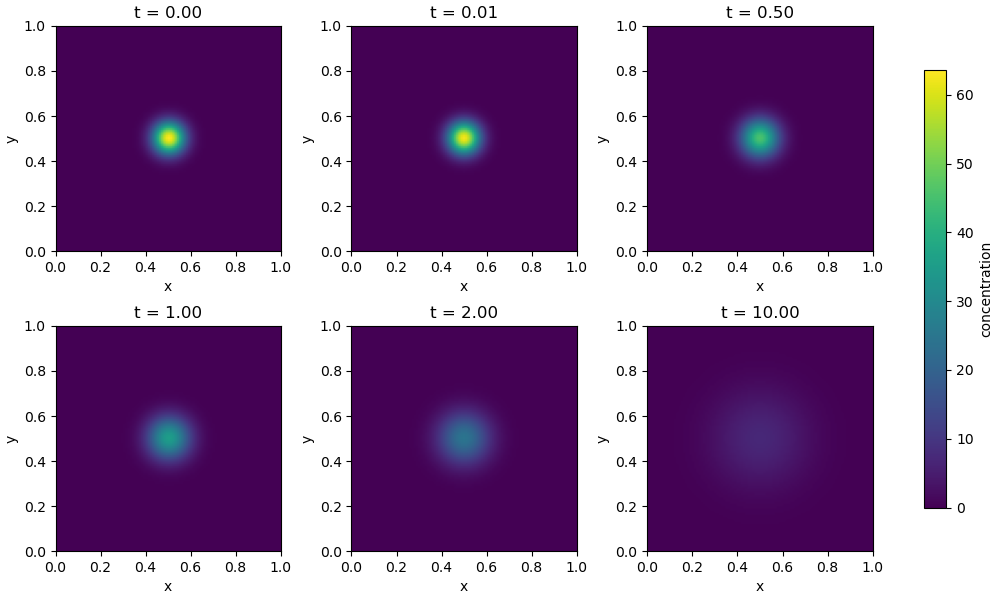

In [18]:
# physical + numerical params
Lx = Ly = 1.0          # domain size
Nx = Ny = 101          # grid points in each direction
dx = Lx/(Nx-1)
dy = Ly/(Ny-1)
D = 1e-3               # diffusivity

# choose dt to satisfy stability: D*dt/dx^2 <= 1/4
dt = 0.2 * dx**2 / D   # safety factor 0.2 < 0.25

# times at which we want snapshots
times = [0.0, 0.01, 0.5, 1, 2, 10]
snapshots = []

# coordinate grids
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# initial condition: normalized gaussian bump in the center
x0, y0 = Lx/2, Ly/2
sigma0 = 0.05

C = np.exp(-((X-x0)**2 + (Y-y0)**2)/(2*sigma0**2))
C /= C.sum()*dx*dy   # optional: normalize to total "mass" = 1

t = 0.0
snap_idx = 0

# record t=0
snapshots.append(C.copy())
snap_idx += 1

# main time loop
t_end = max(times)
alpha = D*dt/dx**2   # assuming dx = dy

while t < t_end:
    # interior update (5-point laplacian)
    C_new = C.copy()
    C_new[1:-1, 1:-1] = (
        C[1:-1, 1:-1]
        + alpha * (
            C[2:  , 1:-1] +
            C[0:-2, 1:-1] +
            C[1:-1, 2:  ] +
            C[1:-1, 0:-2] -
            4*C[1:-1, 1:-1]
        )
    )

    # boundary conditions: zero-flux (neumann), i.e. copy nearest interior
    C_new[0,  :] = C_new[1,  :]
    C_new[-1, :] = C_new[-2, :]
    C_new[:,  0] = C_new[:,  1]
    C_new[:, -1] = C_new[:, -2]

    C = C_new
    t += dt

    # store snapshots when we cross a requested time
    while snap_idx < len(times) and t >= times[snap_idx]:
        snapshots.append(C.copy())
        snap_idx += 1
vmin = 0
vmax = snapshots[0].max()

# plotting: 2x3 grid of snapshots
fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for ax, C_snap, tt in zip(axes.flat, snapshots, times):
    im = ax.imshow(C_snap.T, origin='lower', vmin=vmin, vmax=vmax, extent=[0, Lx, 0, Ly])
    ax.set_title(f"t = {tt:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="concentration")
plt.show()


In [ ]:
from matplotlib.colors import LogNorm

# physical + numerical params
Lx = Ly = 1.0          # domain size
Nx = Ny = 101          # grid points in each direction
dx = Lx/(Nx-1)
dy = Ly/(Ny-1)
D = 1e-3               # diffusivity

# choose dt to satisfy stability: D*dt/dx^2 <= 1/4
dt = 0.2 * dx**2 / D   # safety factor 0.2 < 0.25

# times at which we want snapshots
times = [0.0, 0.01, 0.5, 1, 2, 10]
snapshots = []

# coordinate grids
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# initial condition: normalized gaussian bump in the center
x0, y0 = Lx/2, Ly/2
sigma0 = 0.05

C = np.exp(-((X-x0)**2 + (Y-y0)**2)/(2*sigma0**2))
C /= C.sum()*dx*dy   # optional: normalize to total "mass" = 1

t = 0.0
snap_idx = 0

# record t=0
snapshots.append(C.copy())
snap_idx += 1

# main time loop
t_end = max(times)
alpha = D*dt/dx**2   # assuming dx = dy

while t < t_end:
    # interior update (5-point laplacian)
    C_new = C.copy()
    C_new[1:-1, 1:-1] = (
        C[1:-1, 1:-1]
        + alpha * (
            C[2:  , 1:-1] +
            C[0:-2, 1:-1] +
            C[1:-1, 2:  ] +
            C[1:-1, 0:-2] -
            4*C[1:-1, 1:-1]
        )
    )

    # boundary conditions: zero-flux (neumann), i.e. copy nearest interior
    C_new[0,  :] = C_new[1,  :]
    C_new[-1, :] = C_new[-2, :]
    C_new[:,  0] = C_new[:,  1]
    C_new[:, -1] = C_new[:, -2]

    C = C_new
    t += dt

    # store snapshots when we cross a requested time
    while snap_idx < len(times) and t >= times[snap_idx]:
        snapshots.append(C.copy())
        snap_idx += 1

# make sure everything is strictly positive for log scale
eps = 1e-8
snapshots_pos = []
for C_snap in snapshots:
    C_safe = C_snap.copy()
    C_safe[C_safe < eps] = eps
    snapshots_pos.append(C_safe)


vmin = min(s.min() for s in snapshots_pos)  # > 0 now
vmax = max(s.max() for s in snapshots_pos)

norm = LogNorm(vmin=vmin, vmax=vmax)

# plotting: 2x3 grid of snapshots
fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for ax, C_snap, tt in zip(axes.flat, snapshots_pos, times):
    im = ax.imshow(
        C_snap.T,
        origin='lower',
        extent=[0, Lx, 0, Ly],
        norm=norm              # norm controls scaling; no need for vmin/vmax here
    )
    ax.set_title(f"t = {tt:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="concentration (log)")
plt.show()
